In [2]:
import pandas as pd
import numpy as np

In [3]:
x = np.array([1,2,3])
y = np.array([0,0,1])

In [4]:
xbar = np.mean(x)
ybar = np.mean(y)
ybar

np.float64(0.3333333333333333)

In [5]:
xsum=[]
for i in x:
    xsum.append(i-xbar)

xsum

[np.float64(-1.0), np.float64(0.0), np.float64(1.0)]

In [6]:
ysum = [] 
for i in y:
    ysum.append(i-ybar)

ysum

[np.float64(-0.3333333333333333),
 np.float64(-0.3333333333333333),
 np.float64(0.6666666666666667)]

In [7]:
into=[]
c = 0
for i in xsum:
    into.append(i*ysum[c])
    c += 1

into

[np.float64(0.3333333333333333),
 np.float64(-0.0),
 np.float64(0.6666666666666667)]

In [8]:
xbarsquar = []
for i in xsum:
   xbarsquar.append(i**2)

xbarsquar

[np.float64(1.0), np.float64(0.0), np.float64(1.0)]

In [9]:
xsummation = np.sum(xbarsquar)
xsummation

np.float64(2.0)

In [10]:
intosummation = np.sum(into)
intosummation

np.float64(1.0)

In [11]:
m = intosummation/xsummation
m

np.float64(0.5)

In [12]:
c = ybar - (m * xbar)
c

np.float64(-0.6666666666666667)

In [13]:
ypredict = []
for i in x:
    ans = 1/(1+2.71**(-(m*(i))+-0.6))
    ypredict.append(ans)

ypredict

[np.float64(0.7496306701571698),
 np.float64(0.8313349260484659),
 np.float64(0.8902788062628488)]

In [14]:
df = pd.read_csv("diabetes.csv")

In [15]:
df.head(10)

,glucose,bloodpressure,diabetes
0,40,85,0
1,40,92,0
2,45,63,1
3,45,80,0
4,40,73,1
5,45,82,0
6,40,85,0
7,30,63,1
8,65,65,1
9,45,82,0


In [16]:
df.shape

(995, 3)

In [17]:
df.describe()

,glucose,bloodpressure,diabetes
count,995.000000,995.000000,995.000000
mean,44.306533,79.184925,0.500503
std,6.707567,9.340204,0.500251
min,20.000000,50.000000,0.000000
25%,40.000000,72.000000,0.000000
50%,45.000000,80.000000,1.000000
75%,50.000000,87.000000,1.000000
max,70.000000,100.000000,1.000000


In [18]:
df.isnull().sum()

glucose          0
bloodpressure    0
diabetes         0
dtype: int64

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df.shape

(175, 3)

In [21]:
import seaborn as sns

<Axes: >

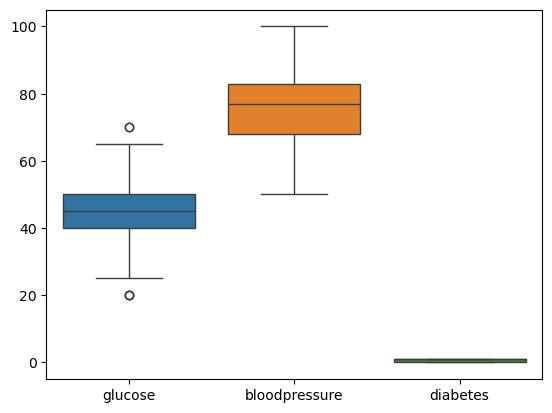

In [22]:
sns.boxplot(data=df)


In [23]:
df.describe()

,glucose,bloodpressure,diabetes
count,175.000000,175.000000,175.000000
mean,44.485714,75.874286,0.714286
std,10.367864,10.515788,0.453050
min,20.000000,50.000000,0.000000
25%,40.000000,68.000000,0.000000
50%,45.000000,77.000000,1.000000
75%,50.000000,83.000000,1.000000
max,70.000000,100.000000,1.000000


In [24]:
q1=40.0
q3 = 50.0

In [25]:
iqr = q3 - q1

In [26]:
ub = q3 +1.5*iqr
lb = q1 - 1.5*iqr

In [27]:
df = df[(df["glucose"]>=lb) & (df["glucose"]<=ub )]

<Axes: >

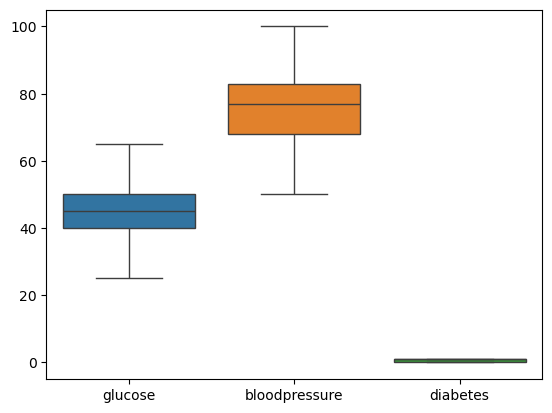

In [28]:
sns.boxplot(data=df)

In [29]:
x = df.drop("diabetes",axis=1)

In [30]:
y = df.diabetes

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20)

In [34]:
model = LogisticRegression()

In [35]:
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [36]:
model.score(x_train,y_train),model.score(x_test,y_test)

(0.8382352941176471, 0.7941176470588235)

In [37]:
ypred = model.predict(x_test)

In [38]:
ypred

array([1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1])

In [40]:
y_test

28     0
642    1
443    1
15     1
2      1
186    1
351    1
14     1
677    1
567    1
149    1
13     0
501    1
241    1
40     1
481    0
59     1
165    1
281    1
3      0
256    1
34     1
209    1
741    0
304    1
237    1
333    0
714    1
51     0
163    0
45     0
22     1
377    1
113    1
Name: diabetes, dtype: int64

In [41]:
from sklearn.metrics import confusion_matrix


In [45]:
cm = confusion_matrix(y_test,ypred)

In [46]:
cm

array([[ 4,  5],
       [ 2, 23]])

In [47]:
import seaborn as sns

<Axes: >

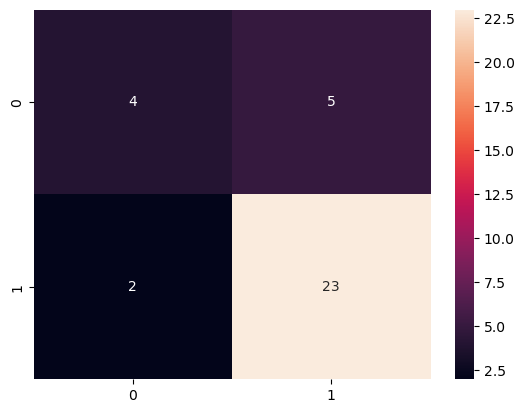

In [48]:
sns.heatmap(cm,annot=True)

In [49]:
from sklearn.metrics import classification_report

In [50]:
print(classification_report(y_test,ypred))

              precision    recall  f1-score   support

           0       0.67      0.44      0.53         9
           1       0.82      0.92      0.87        25

    accuracy                           0.79        34
   macro avg       0.74      0.68      0.70        34
weighted avg       0.78      0.79      0.78        34



In [56]:
78-98

-20

### Logistic regression is a supervised machine learning algorithm that can be used to model the probability of a certain class or event.
### It is used when the data is linearly seperable and the otcome is bonary or dichitimous in nature.

# Limitations:

## The two limitations of using a linear regression model for classification problems are:
## The predicted value may exceed the range (0,1)
## Error rate increases if the data has outliers

# Linear model  : ypredict = mx + c

# Sigmoid function: sigma(z) = 1/(1+e^-z)

# Logisticregression model = ypredict = 1/(1+e-(mx-c))

## TP= The predicted value is positive and its positive
## FP = Type I Error= The predicted value is positive but it false
## FN = Type II error: The predicted value is negative but its positive
## TN = The predicted value is negative and its negative

## True/False: 
## 1. True-Actucal = Predicted(Same Sign)
## 2. Fasle - Actucal != Predicted(Opposite Sign)

## Postive/Negative
## 1. Postive- Predicted Positive
## 2. Negative- Predictive Negative

## Precision:

## Precision tells us how many of the correctly predicted case s actually turned out to be positive

## Precision is a usefull metrics in cases where False Postive is higher concern than False Negative

## Precision = tp/(tp+fp)

## Recall:

## Recall tells us how many of the actucal positive cases we were able to predict correctly with our model
## Recall is a usefull metric in cases where False Negative trumps False Positive

## Recall = True Postive/True Positive + False Negative

## F1 - Score is a harmonic mean of Precision and recall and so it gives a combined ides about these two metrics. IT is maximum when Precision is equal to recall

## F1 Score = 2 * Precision * recall/ Precision + recall